# Modeling and Evaluation
## Overview:
This file aims to build different models and evaluate them.
## Purpose:

## Setup

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models from Assignment 4 + XGBoost
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except ImportError:
    # Fallback if xgboost isn't installed
    XGBClassifier = None

In [2]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

In [29]:

DATA_DIR = "/content/drive/MyDrive/EE344/final project/processed"

# Load the data
X_train = pd.read_parquet(f"{DATA_DIR}/X_train.parquet")
X_test  = pd.read_parquet(f"{DATA_DIR}/X_test.parquet")

y_train_raw = pd.read_parquet(f"{DATA_DIR}/y_train.parquet")["target"]
y_test_raw  = pd.read_parquet(f"{DATA_DIR}/y_test.parquet")["target"]
cols_to_drop = [c for c in ["AI Score (0-100)", "tfidf_ai score"] if c in X_train.columns]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)
y_train = y_train_raw.map({'Hire': 1, 'Reject': 0})
y_test = y_test_raw.map({'Hire': 1, 'Reject': 0})
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining label distribution:")
print(y_train.value_counts())

Training feature shape: (800, 114)
Testing feature shape: (200, 114)

Training label distribution:
target
1    650
0    150
Name: count, dtype: int64


**Preprocessing and Scaling**

In [49]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

**Applying Models**

In [50]:
model_list = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Perceptron": Perceptron(random_state=42),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Multinomial NB": MultinomialNB(),
    "KNN (cosine)": KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

if XGBClassifier:
    model_list["XGBoost"] = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

**Training and Evaluation**

In [51]:
results = []
trained_models = {}
for name, model in model_list.items():
    # Train on scaled data and numeric labels
    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    # Calculate metrics (now pos_label=1 will work correctly)
    train_metrics = metrics(y_train, y_train_pred)
    test_metrics = metrics(y_test, y_test_pred)

    # Store
    results.append([name] + list(train_metrics) + list(test_metrics))

cols = [
    "Model",
    "Train Acc", "Train Prec", "Train Rec", "Train F1",
    "Test Acc", "Test Prec", "Test Rec", "Test F1",
]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 80)
print("\n=== Results (sorted by Test F1) ===")
print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec": "{:.4f}".format,
    "Train Rec": "{:.4f}".format,
    "Train F1": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec": "{:.4f}".format,
    "Test Rec": "{:.4f}".format,
    "Test F1": "{:.4f}".format,
}))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:46:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Results (sorted by Test F1) ===
              Model Train Acc Train Prec Train Rec Train F1 Test Acc Test Prec Test Rec Test F1
            XGBoost    1.0000     1.0000    1.0000   1.0000   0.9600    0.9753   0.9753  0.9753
         Perceptron    0.9812     0.9953    0.9815   0.9884   0.9550    0.9873   0.9568  0.9718
Logistic Regression    0.9838     0.9833    0.9969   0.9901   0.9450    0.9576   0.9753  0.9664
      Decision Tree    1.0000     1.0000    1.0000   1.0000   0.9450    0.9748   0.9568  0.9657
      Random Forest    1.0000     1.0000    1.0000   1.0000   0.9400    0.9464   0.9815  0.9636
         Linear SVM    0.9938     0.9954    0.9969   0.9962   0.9400    0.9630   0.9630  0.9630
     Multinomial NB    0.8213     0.8213    0.9969   0.9006   0.8050    0.8090   0.9938  0.8920
       KNN (cosine)    0.8413     0.8436    0.9877   0.9100   0.8000    0.8144   0.9753  0.8876


,Model,Train Acc,Train Prec,Train Rec,Train F1,Test Acc,Test Prec,Test Rec,Test F1
0,XGBoost,1.0000,1.0000,1.0000,1.0000,0.960,0.9753,0.9753,0.9753
1,Perceptron,0.9812,0.9953,0.9815,0.9884,0.955,0.9873,0.9568,0.9718
2,Logistic Regression,0.9838,0.9833,0.9969,0.9901,0.945,0.9576,0.9753,0.9664
3,Decision Tree,1.0000,1.0000,1.0000,1.0000,0.945,0.9748,0.9568,0.9657
4,Random Forest,1.0000,1.0000,1.0000,1.0000,0.940,0.9464,0.9815,0.9636
5,Linear SVM,0.9938,0.9954,0.9969,0.9962,0.940,0.9630,0.9630,0.9630
6,Multinomial NB,0.8212,0.8213,0.9969,0.9006,0.805,0.8090,0.9938,0.8920
7,KNN (cosine),0.8412,0.8436,0.9877,0.9100,0.800,0.8144,0.9753,0.8876


/tmp/ipykernel_287/1641844635.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=out, x="Test F1", y="Model", palette="viridis")


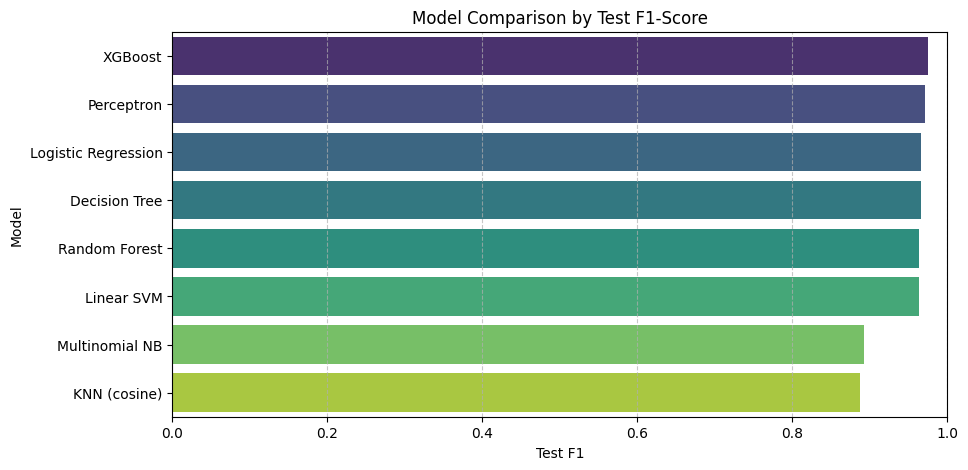

In [52]:
# Assuming 'out' is the DataFrame generated by your loop
# Sort by Test F1 (if not already sorted)
out = out.sort_values("Test F1", ascending=False).reset_index(drop=True)

# Display the rounded table
display(out.round(4))

# Plotting the Model Comparison
plt.figure(figsize=(10, 5))
# Use the column names from your 'out' DataFrame
sns.barplot(data=out, x="Test F1", y="Model", palette="viridis")
plt.title("Model Comparison by Test F1-Score")
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [53]:
print("Model features:", len(importances))
print("Dataframe features:", len(X_train.columns))

Model features: 115
Dataframe features: 114


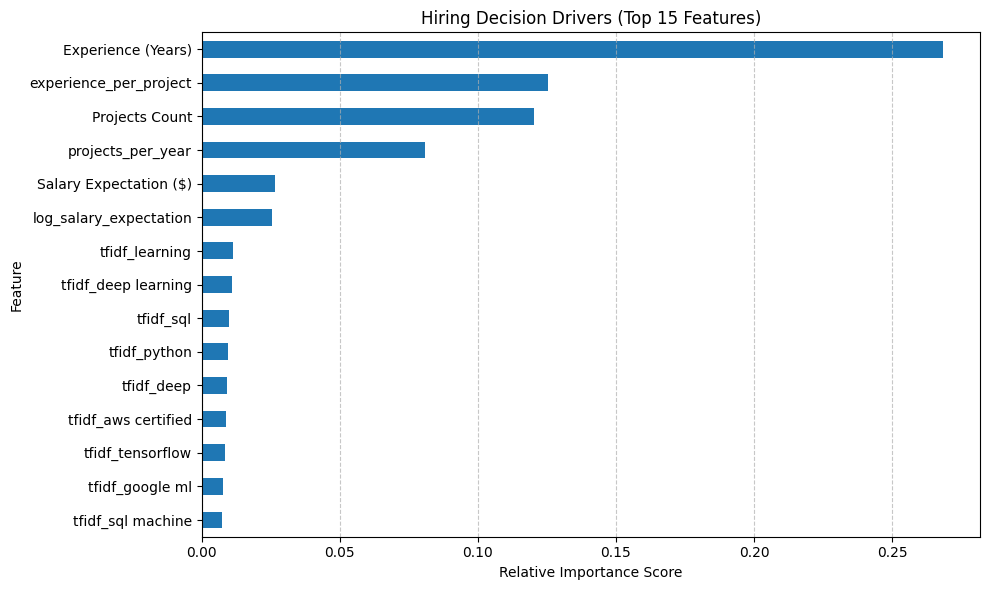

In [54]:
rf_model = trained_models["Random Forest"]

importances = rf_model.feature_importances_
feat_names = X_train_scaled.columns

feature_imp_series = pd.Series(importances, index=feat_names)

top_15_features = feature_imp_series.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_15_features.sort_values().plot(kind="barh")

plt.title("Hiring Decision Drivers (Top 15 Features)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Confusion Matrix for the best model

<Figure size 600x500 with 0 Axes>

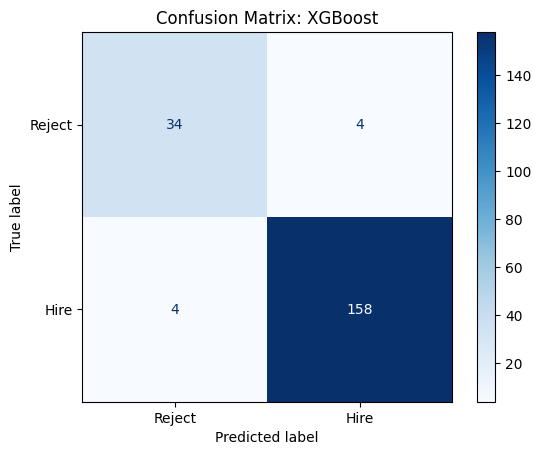

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# get best model name from your results table
best_model_name = out.iloc[0]["Model"]

best_model = trained_models[best_model_name]

# predictions
y_pred = best_model.predict(X_test_scaled)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Reject","Hire"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.grid(False)
plt.show()

Precision-Recall Curve

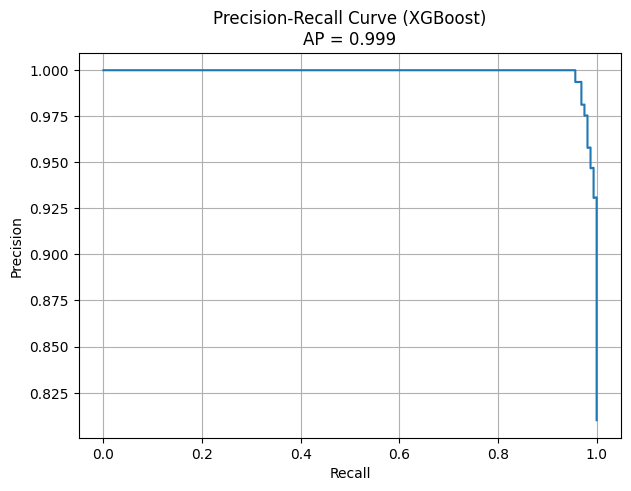

In [56]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# get probability scores
if hasattr(best_model, "predict_proba"):
    y_scores = best_model.predict_proba(X_test_scaled)[:,1]
else:
    y_scores = best_model.decision_function(X_test_scaled)

precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve ({best_model_name})\nAP = {ap:.3f}")
plt.grid(True)
plt.show()

5-Fold Cross-Validation

In [57]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-Validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:17:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:17:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:17:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:17:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Cross-Validation F1 scores: [0.98084291 0.96923077 0.97297297 0.97318008 0.98473282]
Mean CV F1: 0.9761919110273942
